In [1]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import List

# Locals
from utils import *
from dataset import Dataset, SlidingWindowDataset
from models import *
from dlnr import DLNoiseReduction

In [3]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

# Functions

In [5]:
def generate_ts_data(window_size:int, n_var:int, n_samples:int, seed:int=42):
    """
    Generate time series data for testing purposes

    Args:
        window_size (int): size of the sliding window
        n_var (int): number of variables
        n_samples (int): number of samples
        seed (int, optional): seed for random values. Defaults to 42.

    Returns:
        tuple: X and Y dataframes
    """
    np.random.seed(seed)

    # Generar datos con tendencia
    # trend = np.linspace(0, 1, (window_size, n_var))
    # seasonal = np.sin(np.linspace(0, 2 * np.pi, (window_size, n_var)))
    # X = trend + seasonal

    X = 2 * np.random.rand(window_size, n_var) - 1
    A = 2 * np.random.rand(1, window_size) - 1

    X_df = pd.DataFrame(X)
    A_df = pd.DataFrame(A)

    for i in range(n_samples):
        new_X = A_df.values @ X_df.iloc[i:i+window_size].values # + np.random.normal(0, 0.1, (1, n_var))
        # new_X = np.clip(new_X, -1e10, 1e10)  # Limitar el rango antes de la normalización
        new_X /= np.linalg.norm(new_X)  # Normalizar
        new_X = pd.DataFrame(new_X)
        X_df = pd.concat ([X_df, new_X], axis=0, ignore_index=True)

    X_df = X_df[window_size:]
    X_df.reset_index(drop=True, inplace=True)

    return X_df


def polinomial_function_multivariable(x:List[float]) -> float:
    """
    Function that takes in two values x0 and x1 and returns its polinomial value.

    Args:
        x (List[float]): list of values.

    Returns:
        float: result of the polinomial function.
    """
    result = 0
    for i, value in enumerate(x):
        result += value**i
    return result


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

# Data generation

In [6]:
X = generate_ts_data(24, 5, 1000)
X.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1000.0,-0.001105,0.528801,-0.883778,-0.524008,-0.002371,0.526629,0.865317
1,1000.0,-0.000552,0.125444,-0.817715,-0.107312,-0.000510,0.107608,0.694181
2,1000.0,0.000423,0.514087,-0.814156,-0.510256,0.002443,0.511115,0.892497
3,1000.0,0.001395,0.550599,-0.867257,-0.545561,0.000023,0.545474,0.966644
4,1000.0,0.000882,0.371733,-0.637254,-0.365577,-0.003083,0.371032,0.819350


In [7]:
X.columns = [f'X{i}' for i in range(5)]

In [8]:
Y = pd.DataFrame()
for i in range(len(X)):
    row = X.iloc[i].values
    new_y = polinomial_function_multivariable(row)
    Y = pd.concat([Y, pd.DataFrame([new_y], columns=['Y'])], axis=0)
Y.reset_index(drop=True, inplace=True)
Y.describe().T

,count,mean,std,min,25%,50%,75%,max
Y,1000.0,1.293641,0.319781,0.308013,1.058806,1.373536,1.55925,2.012924


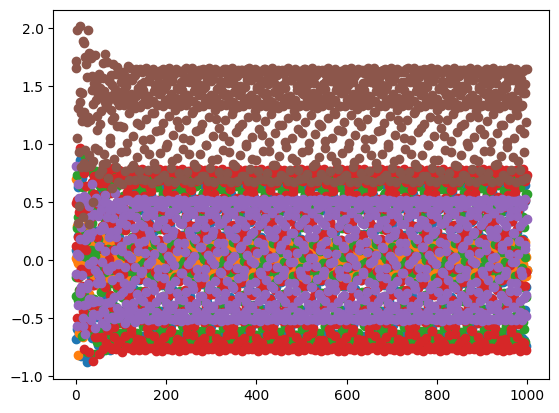

In [9]:
plt.scatter(range(1000), X.iloc[:1000,0])
plt.scatter(range(1000), X.iloc[:1000,1])
plt.scatter(range(1000), X.iloc[:1000,2])
plt.scatter(range(1000), X.iloc[:1000,3])
plt.scatter(range(1000), X.iloc[:1000,4])
plt.scatter(range(1000), Y.iloc[:1000,0])

In [10]:
df = X.copy()
df['Y'] = Y.copy()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
X0,1000.0,-0.001105,0.528801,-0.883778,-0.524008,-0.002371,0.526629,0.865317
X1,1000.0,-0.000552,0.125444,-0.817715,-0.107312,-0.000510,0.107608,0.694181
X2,1000.0,0.000423,0.514087,-0.814156,-0.510256,0.002443,0.511115,0.892497
X3,1000.0,0.001395,0.550599,-0.867257,-0.545561,0.000023,0.545474,0.966644
X4,1000.0,0.000882,0.371733,-0.637254,-0.365577,-0.003083,0.371032,0.819350
Y,1000.0,1.293641,0.319781,0.308013,1.058806,1.373536,1.559250,2.012924


## Scale the data between [0,1]

In [11]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
X0,1000.0,0.504646,0.302328,0.0,0.205689,0.503922,0.806363,1.0
X1,1000.0,0.540489,0.082972,0.0,0.469876,0.540517,0.612028,1.0
X2,1000.0,0.477296,0.301225,0.0,0.178068,0.478480,0.776532,1.0
X3,1000.0,0.473664,0.300234,0.0,0.175416,0.472915,0.770342,1.0
X4,1000.0,0.438099,0.255205,0.0,0.186514,0.435377,0.692217,1.0
Y,1000.0,0.578111,0.187565,0.0,0.440371,0.624972,0.733901,1.0


## Show original correlation matrix

<Axes: >

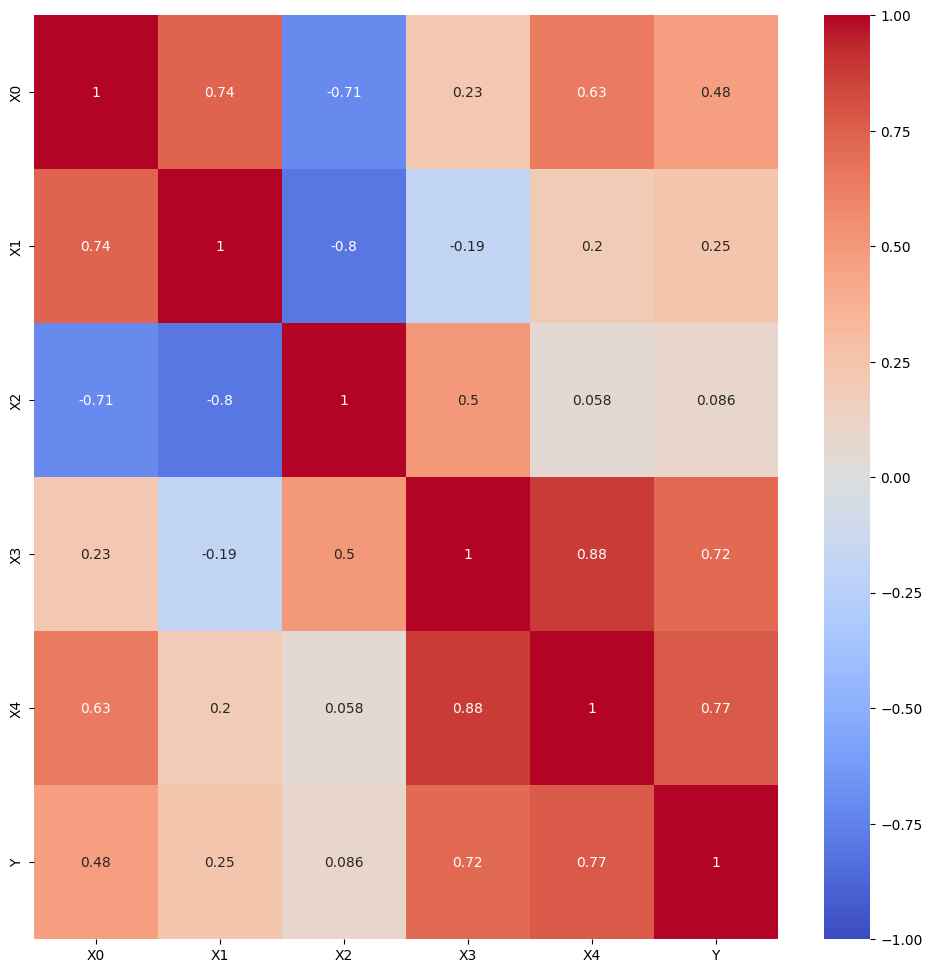

In [12]:
corr_orig = df_scaled.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_orig, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

# No noise XAI Benchmarck

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    df_scaled.drop(columns=['Y'], inplace=False).values, df_scaled['Y'].values, test_size=0.2, shuffle=False
)

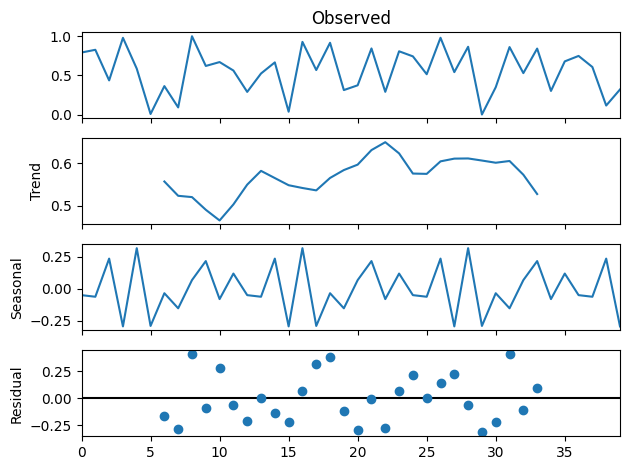

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [17]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {},
    'knn': {
        "n_neighbors": 5,
        "weights": 'uniform',
        "algorithm": 'auto',
        "leaf_size": 30,
        "p": 2,
        "n_jobs": None
    },
    'arima': {
        'order': (1, 1, 0),
        'seasonal_order': (4, 0, 5, 12)
    }
}
xai_benchmark = XAI_benchmark(is_ts = True, model_params = model_params)

In [18]:
xai_benchmark.fit(X_train, y_train)

Fitting Ridge model...
Fitting Partial Least Squares model...
Fitting Decision Tree model...
Fitting Support Vector Machine model...
Fitting K-Nearest Neighbours model...
Fitting ARIMA model...


/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


All models fitted!


In [19]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

{'ridge': {'mse': 0.011388002896358482,
  'rmse': 0.10671458614621752,
  'mae': 0.09131805690298085,
  'mape': 0.19290741277629891,
  'R2': 0.6573668893598457},
 'pls': {'mse': 0.011799905673907918,
  'rmse': 0.10862737074010362,
  'mae': 0.09650629254421517,
  'mape': 0.20261323475132934,
  'R2': 0.6449738884765905},
 'decision_tree': {'mse': 0.0011811781463481974,
  'rmse': 0.03436827237945191,
  'mae': 0.0255027414703921,
  'mape': 0.047972511561376684,
  'R2': 0.9644616579231053},
 'svm': {'mse': 0.0013047814866898435,
  'rmse': 0.0361217591859788,
  'mae': 0.029498940443463417,
  'mape': 0.056513258861583246,
  'R2': 0.9607427796112361},
 'knn': {'mse': 1.449401429788652e-06,
  'rmse': 0.0012039108894717466,
  'mae': 0.0007292594058270897,
  'mape': 0.001467573513114195,
  'R2': 0.9999563915705876},
 'arima': {'mse': 0.007137458206879206,
  'rmse': 0.08448347889900845,
  'mae': 0.0657390091000343,
  'mape': 0.12059893660183113,
  'R2': 0.7852538737701654}}

In [ ]:
plt.plot(predictions['arima'], label='ARIMA', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()

## Add noise

In [ ]:
sigma = 0.07
df_noisy = add_gaussian_noise(df_scaled.copy(), df_scaled.columns, mean=0.0, std=sigma)
df_noisy.describe().T

## Show noisy correlation matrix

In [ ]:
corr_noisy = df_noisy.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_noisy, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

## Plot the original vs noisy data to see the differences

In [ ]:
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.scatter(range(len(df_scaled['Y'])), df_scaled['Y'], alpha=0.2, c='b', label='Original')
plt.legend()
plt.subplot(2, 2, 2)
plt.scatter(range(len(df_noisy['Y'])), df_noisy['Y'], alpha=0.2, c='r', label='Noisy')
plt.legend()
plt.subplot(2, 2, 3)
plt.scatter(range(len(df_noisy['Y'])), df_noisy['Y'], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(df_scaled['Y'])), df_scaled['Y'], alpha=0.1, c='b', label='Original')
plt.legend()

# Noisy XAI Benchmarck

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_noisy.drop(columns=['Y'], inplace=False).values, df_noisy['Y'].values, test_size=0.2, shuffle=False
)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [ ]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto', "max_iter": 1000},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
    'arima': {
        'order': (1, 1, 0),
        'seasonal_order': (4, 0, 5, 12)
    }
}
xai_benchmark = XAI_benchmark(is_ts = True, model_params = model_params)

In [ ]:
xai_benchmark.fit(X_train, y_train)

In [ ]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

In [ ]:
plt.plot(predictions['arima'], label='ARIMA', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()

## Stablish the window size

In [ ]:
window_size = 24

# Train a Model with the Original data

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(df_scaled[df_scaled.columns[:-1]].copy(), df_scaled[df_scaled.columns[-1]].copy(), test_size=0.2, shuffle=False)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [ ]:
# train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
# val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
# test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

In [ ]:
# input_size = X_train.shape[-1] # Número de variables de entrada
# hidden_size = 128  # Número de neuronas en la capa oculta
# output_size = 1  # Predicción de una variable

# # Crear el modelo
# model_orig = LSTMModel(input_size, hidden_size, output_size).to(device)

# # Definir la función de pérdida y el optimizador
# criterion = nn.MSELoss()  # Error cuadrático medio
# optimizer = optim.Adam(model_orig.parameters(), lr=0.001)

In [ ]:
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# trainer_orig = Trainer(
#     model = model_orig,
#     train_generator = train_dataloader,
#     val_generator = val_dataloader,
#     device = device,
#     criterion = criterion,
#     optimizer = optimizer,
#     epoch_scheduler = None,
#     batch_scheduler = None,
#     patience = 10,
#     epochs = 500,
#     checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{0}'),
# )

In [ ]:
# Train the model

# Comment if you want to load the model
# best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_orig.fit(verbose=True)

In [ ]:
# predictions_test = trainer_orig.eval_dataloader(test_dataloader)
# predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])
# len(predictions_flattened)

In [ ]:
# predictions_train = trainer_orig.eval_dataloader(train_dataloader)
# predictions_train_flattened = np.array([y.cpu().detach().numpy() for x in predictions_train for y in x])
# len(predictions_train_flattened)

In [ ]:
# predictions_val = trainer_orig.eval_dataloader(val_dataloader)
# predictions_val_flattened = np.array([y.cpu().detach().numpy() for x in predictions_val for y in x])
# len(predictions_val_flattened)

In [ ]:
# test_to_compare = y_test.values[window_size:]

In [ ]:
# mse_orig = mean_squared_error(test_to_compare, predictions_flattened)
# rmse_orig = np.sqrt(mse_orig)
# mae_orig = mean_absolute_error(test_to_compare, predictions_flattened)
# r2_orig = r2_score(test_to_compare, predictions_flattened)

In [ ]:
# print(f'MSE: {mse_orig:.4f}')
# print(f'RMSE: {rmse_orig:.4f}')
# print(f'MAE: {mae_orig:.4f}')
# print(f'R2: {r2_orig:.4f}')

# Train a Model with Noisy data

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_noisy[df_noisy.columns[:-1]], df_noisy[df_noisy.columns[-1]], test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [ ]:
train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

In [ ]:
input_size = X_train.shape[-1] # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# Crear el modelo
model_noisy = LSTMModel(input_size, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model_noisy.parameters(), lr=0.001)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Load checkpoint
# Comment if you want to train the model
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

In [ ]:
trainer_noisy = Trainer(
    model = model_noisy,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{0.02}'),
)

In [ ]:
# Train the model
# Comment if you want to load the model
best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_noisy.fit(verbose=True)

In [ ]:
predictions_test = trainer_noisy.eval_dataloader(test_dataloader)
predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])
len(predictions_flattened)

In [ ]:
test_to_compare = y_test.values[window_size:]

In [ ]:
mse_noisy = mean_squared_error(test_to_compare, predictions_flattened)
rmse_noisy = np.sqrt(mse_noisy)
mae_noisy = mean_absolute_error(test_to_compare, predictions_flattened)
r2_noisy = r2_score(test_to_compare, predictions_flattened)

In [ ]:
print(f'MSE: {mse_noisy:.4f}')
print(f'RMSE: {rmse_noisy:.4f}')
print(f'MAE: {mae_noisy:.4f}')
print(f'R2: {r2_noisy:.4f}')

# Perform the noise reduction algorithm

In [ ]:
x_cols = df_noisy.columns[:-1]
x_sliding = df_noisy[x_cols].copy()#.reset_index(drop=True)
y_sliding = df_noisy[['Y']].copy()#.reset_index(drop=True)
df_to_denoise = SlidingWindowDataset(x_sliding, y_sliding, window_size=window_size, future=1)
# df_to_denoise = DataLoader(df_to_denoise, batch_size=len(df_to_denoise), shuffle=False)

In [ ]:
model_noisy.train()
dlnr = DLNoiseReduction(model=model_noisy, criterion=criterion, is_ts=True)
dlnr.fit(df_to_denoise)

In [ ]:
X_denoised, y_denoised = dlnr.transform(
    nrr=0.05,
    nr_threshold=0.005,
    max_epochs=1000,
    plot_progress=False,
    denoise_y=False,
)

## Plot the Original VS Noisy VS Denoised Data

In [ ]:
plt.scatter(range(len(df_scaled[df_scaled.columns[2]][100:600])), df_scaled[df_scaled.columns[2]][100:600], alpha=0.1, c='b', label='Original')
plt.scatter(range(len(df_noisy[df_noisy.columns[2]][100:600])), df_noisy[df_noisy.columns[2]][100:600], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(X_denoised[X_denoised.columns[2]][100:600])), X_denoised[X_denoised.columns[2]][100:600], alpha=0.1, c='g', label='Denoised')
plt.legend()

## Show the denoised data correlation matrix

In [ ]:
total_denoise = pd.concat([X_denoised, pd.DataFrame(y_denoised, columns=['Y'])], axis=1)
corr_denoised = pd.DataFrame(total_denoise).corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_denoised, annot=True, cmap='coolwarm', vmin=-1, vmax=1)


## Print some metrics

- rmse(noisy, orig) > rmse(denoised, orig): el error entre las matrices de correlación de los datos ruidosos frente a los originales debe ser mayor al error entre las matrices de correlación de los datos filtrados y los originales.
- la correlación media de los datos filtrados debe ser mayor que la correlación media de los datos con ruido.

In [ ]:
np.sqrt(mean_squared_error(corr_noisy, corr_orig)) > np.sqrt(mean_squared_error(corr_denoised, corr_orig))

In [ ]:
np.mean(corr_denoised) > np.mean(corr_noisy)

## Show the difference between the correlation matrix of the denoised data VS noisy data

In [ ]:
diff_corr = corr_denoised - corr_noisy
plt.figure(figsize=(12, 12))
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', vmin=-0.0006, vmax=0.0006)

# Train a Model with the Denoised data

In [ ]:
# Dividir en conjunto de entrenamiento y prueba
X_train_denoised, X_test_denoised, y_train_denoised, y_test_denoised = train_test_split(X_denoised, y_denoised['Y'], test_size=0.2, shuffle=False)
X_train_denoised, X_val_denoised, y_train_denoised, y_val_denoised = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [ ]:
train_dataset = SlidingWindowDataset(X_train_denoised, y_train_denoised, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val_denoised, y_val_denoised, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test_denoised, y_test_denoised, window_size=window_size, future=1)

In [ ]:
input_size = X_train.shape[-1] # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# Crear el modelo
model_denoised = LSTMModel(input_size, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model_denoised.parameters(), lr=0.001)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Load checkpoint
# Comment if you want to train the model
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

In [ ]:
trainer_denoised = Trainer(
    model = model_denoised,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'syntetic_ts', f'lstm_sigma{sigma}'),
)

In [ ]:
# Train the model
# Comment if you want to load the model
best_model, train_losses, val_losses, train_loss_when_best_val_loss, best_val_loss = trainer_denoised.fit(verbose=True)

In [ ]:
predictions_test = trainer_denoised.eval_dataloader(test_dataloader)
predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions_test for y in x])
len(predictions_flattened)

In [ ]:
test_to_compare = y_test.values[window_size:]

In [ ]:
mse_denoised = mean_squared_error(test_to_compare, predictions_flattened)
rmse_denoised = np.sqrt(mse_denoised)
mae_denoised = mean_absolute_error(test_to_compare, predictions_flattened)
r2_denoised = r2_score(test_to_compare, predictions_flattened)

In [ ]:
print(f'MSE: {mse_denoised:.4f}')
print(f'RMSE: {rmse_denoised:.4f}')
print(f'MAE: {mae_denoised:.4f}')
print(f'R2: {r2_denoised:.4f}')

# Denoised XAI Benchmarck

In [ ]:
y_train_denoised = trainer_denoised.eval_dataloader(train_dataloader)
y_train_denoised = np.array([y.cpu().detach().numpy() for x in y_train_denoised for y in x])
len(y_train_denoised)

In [ ]:
X_train_denoised.iloc[window_size:]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_denoised.iloc[window_size:], y_train_denoised, test_size=0.2, shuffle=False
)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición estacional
decomposition = seasonal_decompose(y_train[:40], model="additive", period=12)
decomposition.plot()
plt.show()

In [ ]:
model_params = {
    'ridge': {"alpha": 1.0},
    'pls': {"n_components": 1},
    'tree': {"max_depth": 5},
    'svm': {"dual": 'auto', "max_iter": 1000},
    'knn': {"n_neighbors": 5, "weights": 'uniform', "algorithm": 'auto', "leaf_size": 30, "p": 2, "n_jobs": None},
    'arima': {
        'order': (1, 1, 0),
        'seasonal_order': (4, 0, 5, 12)
    }
}
xai_benchmark = XAI_benchmark(is_ts = True, model_params = model_params)

In [ ]:
xai_benchmark.fit(X_train, y_train)

In [ ]:
predictions, metrics = xai_benchmark.predict(X_test, y_test, get_metrics=True)
metrics

In [ ]:
plt.plot(predictions['arima'], label='ARIMA', alpha=0.7)
plt.plot(y_test, label='True', alpha=0.5)
plt.legend()